In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
df = pd.read_csv(r"C:\Users\acer\OneDrive\Documents\AI_Sales_Forecasting\data\raw\sales_data.csv")


In [3]:
print(df.columns)

Index(['order_id', 'order_date', 'city', 'state', 'sales_channel',
       'store_type', 'product_category', 'quantity', 'unit_price',
       'discount_percent', 'net_sales_amount', 'payment_mode',
       'customer_gender', 'customer_age'],
      dtype='str')


In [4]:
target = 'net_sales_amount'

df = df.dropna(subset=[target])

print("Missing values removed successfully!")
print(df[target].isnull().sum())

Missing values removed successfully!
0


In [5]:
threshold = df[target].median()

In [6]:
df["Sales_Class"] = (df[target] >= threshold).astype(int)

In [7]:
X = df.drop(columns=[target, "Sales_Class"])
y = df["Sales_Class"]

In [8]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns


C:\Users\acer\AppData\Local\Temp\ipykernel_7072\2657737324.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [10]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [12]:
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


In [13]:
y_pred = model.predict(X_test)


In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n----- Model Evaluation -----")
print("Accuracy  :", round(accuracy,10))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


----- Model Evaluation -----
Accuracy  : 0.9198
Precision : 0.9185
Recall    : 0.9214
F1 Score  : 0.9199

Confusion Matrix:
[[13773  1227]
 [ 1179 13821]]


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

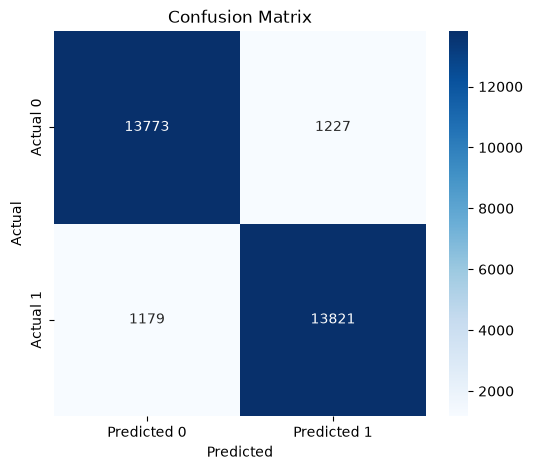

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

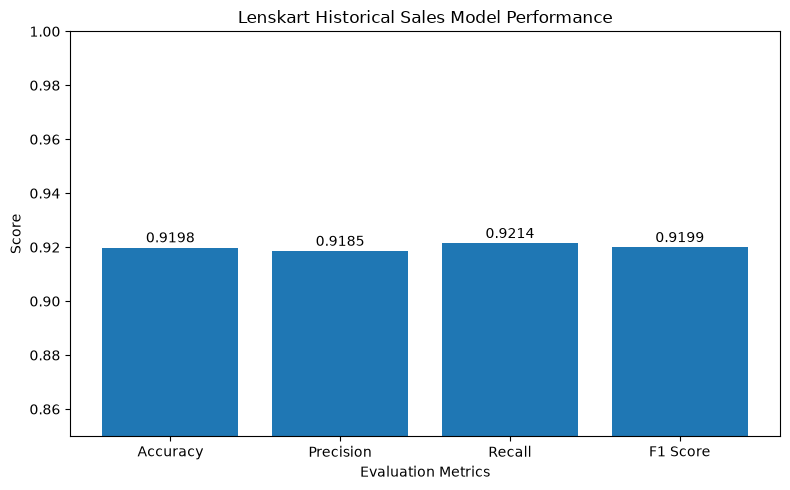

In [23]:
import matplotlib.pyplot as plt

# Model evaluation values
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
scores = [0.9198, 0.9185, 0.9214, 0.9199]

# Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, scores)

# Add values on top of bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.002,
        f"{score:.4f}",
        ha="center"
    )

plt.title("Lenskart Historical Sales Model Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

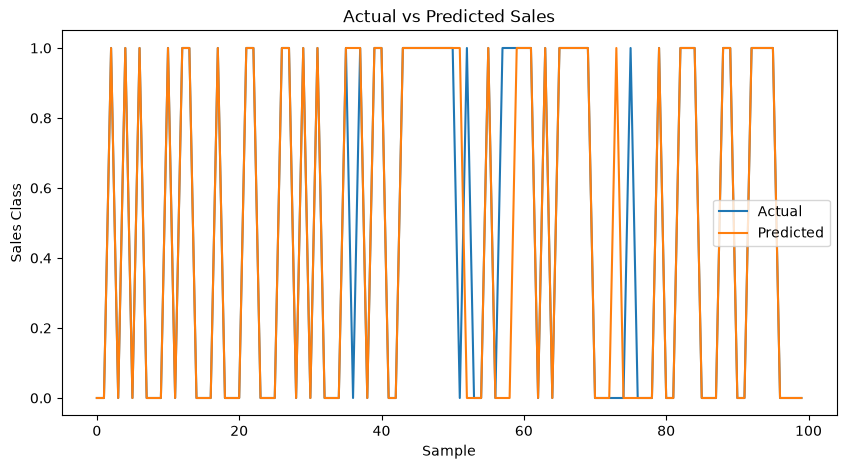

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')

plt.xlabel('Sample')
plt.ylabel('Sales Class')
plt.title('Actual vs Predicted Sales')
plt.legend()

plt.show()